# Clean vs Dirty Image Quality + EfficientNet-B0 Pipeline

This notebook trains a binary clean/dirty classifier and then wraps it in an OpenCV quality gatekeeper.

Dataset used: public **Messy vs Clean Room** dataset/project by Guanqiao Ding. The original project describes clean vs messy scene classification with train/validation splits. In this notebook, `messy` is treated as the `dirty` class.

Notebook flow:

1. Download the online clean/messy dataset from GitHub.
2. Run OpenCV quality checks for blur and brightness.
3. Fine-tune torchvision EfficientNet-B0 for clean vs dirty classification.
4. Evaluate accuracy on a held-out test split.
5. Run final URL-based pass/fail tests cell by cell.

Source project: https://github.com/GuanqiaoDing/messy-room-classifier


In [1]:
# Run this once if the notebook environment does not already have these packages.
# In Jupyter, %pip installs into the current kernel environment.
# CPU-only PyTorch avoids downloading large CUDA packages on normal laptops.
%pip install -q opencv-python requests numpy matplotlib tqdm
%pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cpu
    



Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import io
import math
import random
import zipfile
from pathlib import Path
from typing import Optional, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0
from tqdm.auto import tqdm

# -----------------------------
BLUR_THRESHOLD = 100.0
MIN_BRIGHTNESS = 30.0
MAX_BRIGHTNESS = 240.0
FAIL_SCORE_THRESHOLD = 0.75

SEED = 42
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
FREEZE_BACKBONE = True

CLASS_NAMES = ['clean', 'dirty']
CLEAN_CLASS_INDEX = 0
DIRTY_CLASS_INDEX = 1

DATA_URL = 'https://raw.githubusercontent.com/GuanqiaoDing/messy-room-classifier/master/data/room_dataset.npy'
DATA_DIR = Path('data_clean_dirty')
DATA_FILE = DATA_DIR / 'room_dataset.npy'
MODEL_DIR = Path('models')
MODEL_PATH = MODEL_DIR / 'clean_dirty_efficientnet_b0.pt'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


Using device: cpu


/home/shumail/PRIV/.venv-clean-dirty/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 0: Fetch Data

This section downloads the public clean/messy room dataset and loads it into NumPy arrays. The dataset was originally built with OpenCV, so the image arrays are in BGR channel order.


In [3]:
def download_file(url: str, output_path: Path, timeout: int = 60) -> Path:
    """Download a file from a URL if it is not already present."""
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists() and output_path.stat().st_size > 0:
        print(f'Using existing file: {output_path} ({output_path.stat().st_size / 1024 / 1024:.1f} MB)')
        return output_path

    print(f'Downloading: {url}')
    response = requests.get(url, stream=True, timeout=timeout)
    response.raise_for_status()

    total = int(response.headers.get('content-length', 0))
    with output_path.open('wb') as f, tqdm(total=total, unit='B', unit_scale=True) as bar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                bar.update(len(chunk))

    print(f'Saved: {output_path} ({output_path.stat().st_size / 1024 / 1024:.1f} MB)')
    return output_path


def load_clean_dirty_dataset(data_file: Path) -> Tuple[np.ndarray, np.ndarray]:
    """Load the source NumPy dataset and combine train/validation arrays."""
    # The file contains a Python tuple saved by np.save, so allow_pickle is required.
    (x_train, y_train), (x_val, y_val) = np.load(data_file, allow_pickle=True)

    images = np.concatenate([x_train, x_val], axis=0).astype(np.uint8)
    labels = np.concatenate([y_train, y_val], axis=0).astype(np.int64)

    print('Images shape:', images.shape)
    print('Labels shape:', labels.shape)
    print('Class counts:', {CLASS_NAMES[i]: int((labels == i).sum()) for i in np.unique(labels)})
    return images, labels


download_file(DATA_URL, DATA_FILE)
images_bgr, labels = load_clean_dirty_dataset(DATA_FILE)


Using existing file: data_clean_dirty/room_dataset.npy (80.8 MB)


Images shape: (212, 299, 299, 3)
Labels shape: (212,)
Class counts: {'clean': 106, 'dirty': 106}


## Download a Single Image From a URL

This is the requested URL-to-OpenCV function. It downloads an image and decodes it as a NumPy/OpenCV BGR image.


In [4]:
def download_image_from_url(url: str, timeout: int = 15) -> np.ndarray:
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()

    image_bytes = np.frombuffer(response.content, dtype=np.uint8)
    image_bgr = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)

    if image_bgr is None:
        raise ValueError('Downloaded content could not be decoded as an image.')

    return image_bgr


## Step 1: OpenCV Quality Gatekeeper

The gatekeeper rejects images before ML classification if they are too blurry or badly lit.


In [5]:
def opencv_quality_gatekeeper(
    image_bgr: np.ndarray,
    blur_threshold: float = BLUR_THRESHOLD,
    min_brightness: float = MIN_BRIGHTNESS,
    max_brightness: float = MAX_BRIGHTNESS,
) -> Tuple[bool, str, dict]:
    grayscale = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    laplacian_variance = float(cv2.Laplacian(grayscale, cv2.CV_64F).var())
    average_brightness = float(np.mean(grayscale))

    metrics = {
        'laplacian_variance': laplacian_variance,
        'average_brightness': average_brightness,
    }

    if laplacian_variance < blur_threshold:
        return False, 'FAIL: Image too blurry', metrics

    if average_brightness < min_brightness or average_brightness > max_brightness:
        return False, 'FAIL: Image lighting is bad', metrics

    return True, 'PASS: Image quality is acceptable', metrics


def audit_dataset_quality(images: np.ndarray, max_images: Optional[int] = None) -> None:
    """Quickly report how many dataset images fail the OpenCV gatekeeper."""
    subset = images if max_images is None else images[:max_images]
    failures = {'blur': 0, 'lighting': 0}

    for image in subset:
        passed, message, _ = opencv_quality_gatekeeper(image)
        if not passed and 'blurry' in message:
            failures['blur'] += 1
        elif not passed and 'lighting' in message:
            failures['lighting'] += 1

    print(f'Checked {len(subset)} images')
    print(failures)


audit_dataset_quality(images_bgr)


Checked 212 images
{'blur': 1, 'lighting': 0}


## Visualize Sample Data

The source labels are `0 = clean` and `1 = messy`; this notebook treats `messy` as `dirty`.


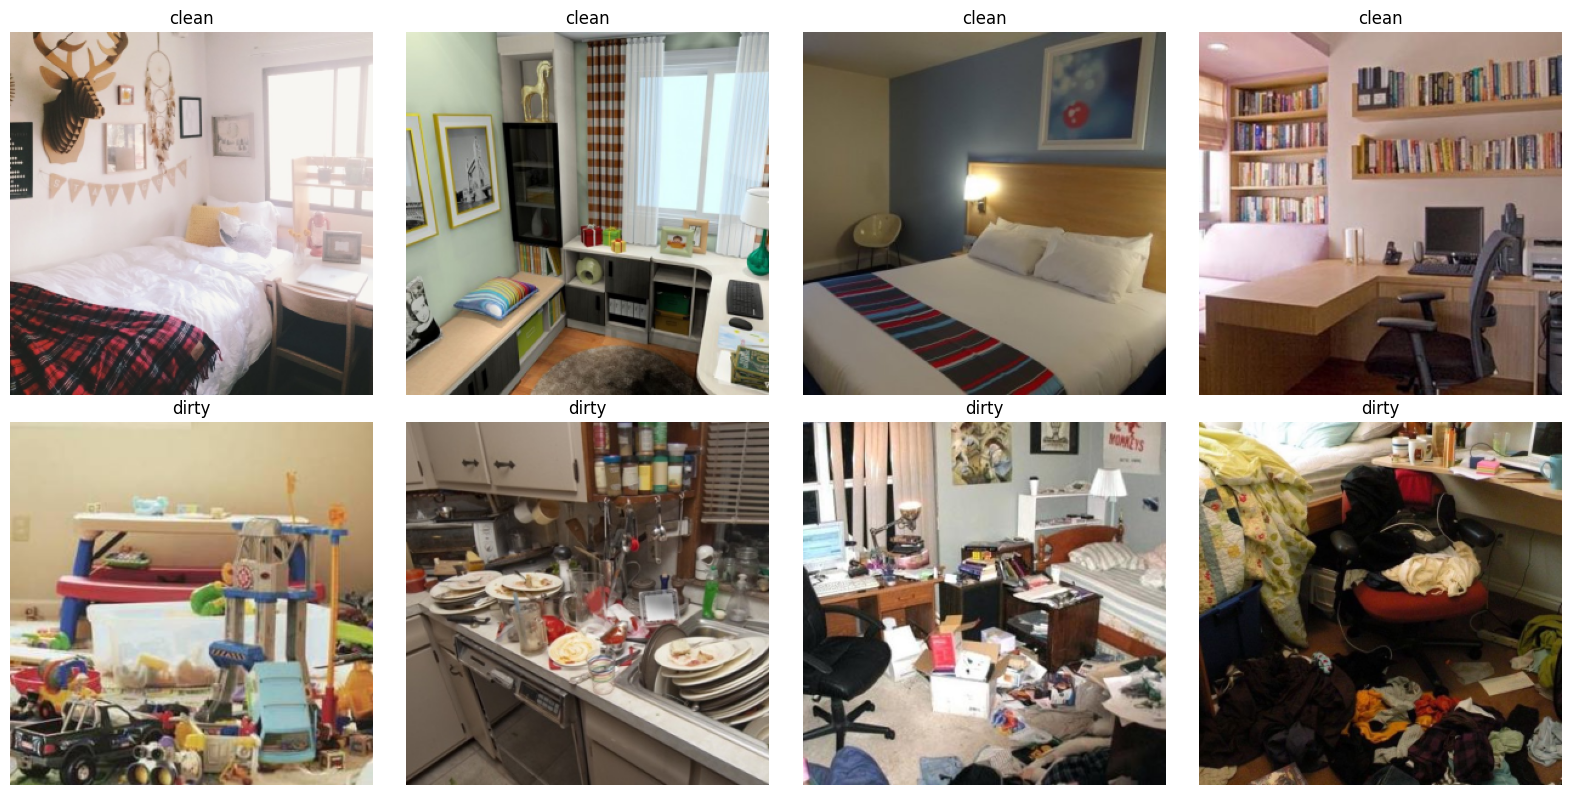

In [6]:
def show_samples(images: np.ndarray, labels: np.ndarray, count_per_class: int = 4) -> None:
    """Show a few examples from each class."""
    selected_indices = []
    for class_index in sorted(np.unique(labels)):
        class_indices = np.where(labels == class_index)[0]
        selected_indices.extend(class_indices[:count_per_class])

    cols = count_per_class
    rows = len(selected_indices) // cols
    plt.figure(figsize=(4 * cols, 4 * rows))

    for plot_index, data_index in enumerate(selected_indices, start=1):
        image_rgb = cv2.cvtColor(images[data_index], cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, plot_index)
        plt.imshow(image_rgb)
        plt.title(CLASS_NAMES[int(labels[data_index])])
        plt.axis('off')

    plt.tight_layout()
    plt.show()


show_samples(images_bgr, labels)


## Train/Validation/Test Split

The GitHub file contains train and validation arrays. To include explicit accuracy test cases, this notebook combines them and creates a stratified 70/15/15 train/validation/test split.


In [7]:
def stratified_split_indices(
    labels: np.ndarray,
    train_ratio: float = 0.70,
    val_ratio: float = 0.15,
    seed: int = SEED,
) -> Tuple[list[int], list[int], list[int]]:
    """Create deterministic stratified train/validation/test indices."""
    rng = np.random.default_rng(seed)
    train_indices: list[int] = []
    val_indices: list[int] = []
    test_indices: list[int] = []

    for class_index in np.unique(labels):
        class_indices = np.where(labels == class_index)[0]
        rng.shuffle(class_indices)

        n_total = len(class_indices)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        train_indices.extend(class_indices[:n_train].tolist())
        val_indices.extend(class_indices[n_train:n_train + n_val].tolist())
        test_indices.extend(class_indices[n_train + n_val:].tolist())

    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    rng.shuffle(test_indices)
    return train_indices, val_indices, test_indices


train_idx, val_idx, test_idx = stratified_split_indices(labels)
print('Split sizes:', {'train': len(train_idx), 'val': len(val_idx), 'test': len(test_idx)})
print('Test class counts:', {CLASS_NAMES[i]: int((labels[test_idx] == i).sum()) for i in np.unique(labels)})


Split sizes: {'train': 148, 'val': 30, 'test': 34}
Test class counts: {'clean': 17, 'dirty': 17}


## PyTorch Dataset and DataLoaders

EfficientNet-B0 expects RGB images normalized with ImageNet mean/std. The dataset class converts the OpenCV BGR arrays to RGB before applying torchvision transforms.


In [8]:
class CleanDirtyRoomDataset(Dataset):
    """PyTorch dataset wrapping OpenCV BGR image arrays and integer labels."""

    def __init__(self, images_bgr: np.ndarray, labels: np.ndarray, transform: Optional[transforms.Compose] = None):
        self.images_bgr = images_bgr
        self.labels = labels
        self.transform = transform

    def __len__(self) -> int:
        return len(self.images_bgr)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        image_rgb = cv2.cvtColor(self.images_bgr[index], cv2.COLOR_BGR2RGB)
        label = int(self.labels[index])

        if self.transform is not None:
            image_tensor = self.transform(image_rgb)
        else:
            image_tensor = transforms.ToTensor()(image_rgb)

        return image_tensor, torch.tensor(label, dtype=torch.long)


weights = EfficientNet_B0_Weights.DEFAULT
imagenet_mean = weights.transforms().mean
imagenet_std = weights.transforms().std

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset = Subset(CleanDirtyRoomDataset(images_bgr, labels, train_transform), train_idx)
val_dataset = Subset(CleanDirtyRoomDataset(images_bgr, labels, eval_transform), val_idx)
test_dataset = Subset(CleanDirtyRoomDataset(images_bgr, labels, eval_transform), test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


## Step 2: EfficientNet-B0 Classification Model

This loads torchvision's pretrained EfficientNet-B0 and replaces the ImageNet classifier with a 2-class clean/dirty head.


In [9]:
def build_efficientnet_b0_binary_model(freeze_backbone: bool = FREEZE_BACKBONE) -> nn.Module:
    """Load pretrained EfficientNet-B0 and replace the final classifier with 2 outputs."""
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

    if freeze_backbone:
        for parameter in model.features.parameters():
            parameter.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, len(CLASS_NAMES))
    return model


model = build_efficientnet_b0_binary_model().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print(model.classifier)


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


## Training and Evaluation Helpers


In [10]:
def run_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: Optional[torch.optim.Optimizer] = None,
) -> dict:
    """Train or evaluate one epoch depending on whether optimizer is provided."""
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    correct = 0
    total = 0

    for batch_images, batch_labels in tqdm(loader, leave=False):
        batch_images = batch_images.to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            logits = model(batch_images)
            loss = criterion(logits, batch_labels)

            if is_training:
                loss.backward()
                optimizer.step()

        total_loss += float(loss.item()) * batch_images.size(0)
        predictions = logits.argmax(dim=1)
        correct += int((predictions == batch_labels).sum().item())
        total += int(batch_labels.size(0))

    return {
        'loss': total_loss / max(total, 1),
        'accuracy': correct / max(total, 1),
    }


def evaluate_model(model: nn.Module, loader: DataLoader) -> dict:
    """Evaluate without gradient tracking."""
    with torch.inference_mode():
        return run_one_epoch(model, loader, criterion, optimizer=None)


## Train EfficientNet-B0

This dataset is small, so 3-10 epochs is usually enough for a baseline. If validation accuracy is unstable, lower the learning rate or unfreeze the backbone after a few epochs.


In [11]:
history = []
best_val_accuracy = -1.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_one_epoch(model, train_loader, criterion, optimizer)
    val_metrics = evaluate_model(model, val_loader)

    row = {
        'epoch': epoch,
        'train_loss': train_metrics['loss'],
        'train_accuracy': train_metrics['accuracy'],
        'val_loss': val_metrics['loss'],
        'val_accuracy': val_metrics['accuracy'],
    }
    history.append(row)

    if val_metrics['accuracy'] > best_val_accuracy:
        best_val_accuracy = val_metrics['accuracy']
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {row['train_loss']:.4f}, acc {row['train_accuracy']:.3f} | "
        f"val loss {row['val_loss']:.4f}, acc {row['val_accuracy']:.3f}"
    )

if best_state is not None:
    model.load_state_dict(best_state)
    print(f'Loaded best validation model with accuracy: {best_val_accuracy:.3f}')


  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:00<00:07,  1.26it/s]

 20%|██        | 2/10 [00:01<00:06,  1.21it/s]

 30%|███       | 3/10 [00:02<00:05,  1.22it/s]

 40%|████      | 4/10 [00:03<00:04,  1.22it/s]

...

100%|██████████| 10/10 [00:07<00:00,  1.57it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

 50%|█████     | 1/2 [00:00<00:00,  1.29it/s]

100%|██████████| 2/2 [00:01<00:00,  1.44it/s]

Epoch 05/5 | train loss 0.3311, acc 0.912 | val loss 0.3104, acc 0.867
Loaded best validation model with accuracy: 0.900


## Step 3 Test Cases: Accuracy, Confusion Matrix, and Sample Predictions

This is the held-out accuracy test. These samples are not used during training.


In [12]:
def collect_predictions(model: nn.Module, loader: DataLoader) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return true labels, predicted labels, and dirty probabilities."""
    model.eval()
    all_true = []
    all_pred = []
    all_dirty_prob = []

    with torch.inference_mode():
        for batch_images, batch_labels in loader:
            logits = model(batch_images.to(DEVICE))
            probabilities = torch.softmax(logits, dim=1).cpu()
            predictions = probabilities.argmax(dim=1)

            all_true.extend(batch_labels.numpy().tolist())
            all_pred.extend(predictions.numpy().tolist())
            all_dirty_prob.extend(probabilities[:, DIRTY_CLASS_INDEX].numpy().tolist())

    return np.array(all_true), np.array(all_pred), np.array(all_dirty_prob)


def print_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray) -> None:
    matrix = np.zeros((len(CLASS_NAMES), len(CLASS_NAMES)), dtype=int)
    for true_label, predicted_label in zip(y_true, y_pred):
        matrix[int(true_label), int(predicted_label)] += 1

    print('Confusion matrix rows=true, cols=predicted')
    print('Labels:', CLASS_NAMES)
    print(matrix)

    for class_index, class_name in enumerate(CLASS_NAMES):
        tp = matrix[class_index, class_index]
        fp = matrix[:, class_index].sum() - tp
        fn = matrix[class_index, :].sum() - tp
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        print(f'{class_name:>5} | precision={precision:.3f} recall={recall:.3f}')


test_metrics = evaluate_model(model, test_loader)
y_true, y_pred, dirty_probs = collect_predictions(model, test_loader)
print(f"Test loss: {test_metrics['loss']:.4f}")
print(f"Test accuracy: {test_metrics['accuracy']:.3f}")
print_confusion_matrix(y_true, y_pred)


  0%|          | 0/3 [00:00<?, ?it/s]

 33%|███▎      | 1/3 [00:00<00:01,  1.45it/s]

 67%|██████▋   | 2/3 [00:01<00:00,  1.46it/s]

100%|██████████| 3/3 [00:01<00:00,  2.37it/s]

Test loss: 0.5453
Test accuracy: 0.853
Confusion matrix rows=true, cols=predicted
Labels: ['clean', 'dirty']
[[15  2]
 [ 3 14]]
clean | precision=0.833 recall=0.882
dirty | precision=0.875 recall=0.824


## Expanded Evaluation Metrics

This section gives a fuller evaluation of the held-out test split: confusion matrix, accuracy, precision, recall, F1, specificity, false positive rate, and false negative rate.

For this notebook, `dirty` is the positive class because the fail condition is based on detecting dirty/messy images.


Confusion counts where dirty is positive:
TP dirty correctly detected: 14
TN clean correctly accepted: 15
FP clean incorrectly marked dirty: 2
FN dirty incorrectly marked clean: 3

                   accuracy: 0.853
          balanced_accuracy: 0.853
            precision_dirty: 0.875
   recall_dirty_sensitivity: 0.824
          specificity_clean: 0.882
                   f1_dirty: 0.848
        false_positive_rate: 0.118
        false_negative_rate: 0.176


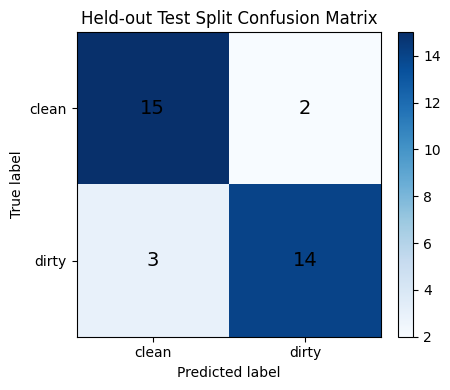

In [13]:
def compute_binary_classification_metrics(y_true: np.ndarray, y_pred: np.ndarray, positive_label: int = DIRTY_CLASS_INDEX) -> dict:
    """Compute binary classification metrics without requiring scikit-learn."""
    negative_label = CLEAN_CLASS_INDEX if positive_label == DIRTY_CLASS_INDEX else DIRTY_CLASS_INDEX

    tp = int(((y_true == positive_label) & (y_pred == positive_label)).sum())
    tn = int(((y_true == negative_label) & (y_pred == negative_label)).sum())
    fp = int(((y_true == negative_label) & (y_pred == positive_label)).sum())
    fn = int(((y_true == positive_label) & (y_pred == negative_label)).sum())

    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)
    f1 = (2 * precision * recall) / max(precision + recall, 1e-12)
    false_positive_rate = fp / max(fp + tn, 1)
    false_negative_rate = fn / max(fn + tp, 1)
    balanced_accuracy = (recall + specificity) / 2

    return {
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "accuracy": accuracy,
        "precision_dirty": precision,
        "recall_dirty_sensitivity": recall,
        "specificity_clean": specificity,
        "f1_dirty": f1,
        "false_positive_rate": false_positive_rate,
        "false_negative_rate": false_negative_rate,
        "balanced_accuracy": balanced_accuracy,
    }


def print_metric_report(metrics: dict) -> None:
    """Pretty-print metric values."""
    print("Confusion counts where dirty is positive:")
    print(f"TP dirty correctly detected: {metrics['tp']}")
    print(f"TN clean correctly accepted: {metrics['tn']}")
    print(f"FP clean incorrectly marked dirty: {metrics['fp']}")
    print(f"FN dirty incorrectly marked clean: {metrics['fn']}")
    print()
    for key in [
        "accuracy",
        "balanced_accuracy",
        "precision_dirty",
        "recall_dirty_sensitivity",
        "specificity_clean",
        "f1_dirty",
        "false_positive_rate",
        "false_negative_rate",
    ]:
        print(f"{key:>27}: {metrics[key]:.3f}")


def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, title: str = "Confusion Matrix") -> None:
    """Plot a 2x2 confusion matrix using matplotlib."""
    matrix = np.zeros((len(CLASS_NAMES), len(CLASS_NAMES)), dtype=int)
    for true_label, predicted_label in zip(y_true, y_pred):
        matrix[int(true_label), int(predicted_label)] += 1

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(range(len(CLASS_NAMES)), CLASS_NAMES)
    ax.set_yticks(range(len(CLASS_NAMES)), CLASS_NAMES)

    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            ax.text(col, row, str(matrix[row, col]), ha="center", va="center", color="black", fontsize=14)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


test_metrics_expanded = compute_binary_classification_metrics(y_true, y_pred)
print_metric_report(test_metrics_expanded)
plot_confusion_matrix(y_true, y_pred, title="Held-out Test Split Confusion Matrix")


## External Mini Test Set From Wikimedia Commons

This is a small, manually labeled, online test set that is separate from the training dataset. It checks basic generalization on different image sources.

Important: this is only a small smoke test, not a replacement for a large independent benchmark. The labels are assigned manually from the image titles/descriptions.

If a URL fails to download in your network, skip that row or replace it with another image URL.


In [14]:
EXTERNAL_TEST_SET = [
    {
        "name": "tidy_bedroom_greenbank",
        "label": CLEAN_CLASS_INDEX,
        "url": "https://commons.wikimedia.org/wiki/Special:FilePath/Tidy%20bedroom%20-%20Greenbank%20May%201984.jpg",
    },
    {
        "name": "simple_bedroom",
        "label": CLEAN_CLASS_INDEX,
        "url": "https://commons.wikimedia.org/wiki/Special:FilePath/A%20bedroom.JPG",
    },
    {
        "name": "amazing_bedroom",
        "label": CLEAN_CLASS_INDEX,
        "url": "https://commons.wikimedia.org/wiki/Special:FilePath/An%20amazing%20bedroom%20%2814730950393%29.jpg",
    },
    {
        "name": "very_messy_room",
        "label": DIRTY_CLASS_INDEX,
        "url": "https://commons.wikimedia.org/wiki/Special:FilePath/A%20Very%20Messy%20Room.jpg",
    },
    {
        "name": "untidy_room",
        "label": DIRTY_CLASS_INDEX,
        "url": "https://commons.wikimedia.org/wiki/Special:FilePath/Untidy%20room.JPG",
    },
    {
        "name": "my_messy_room",
        "label": DIRTY_CLASS_INDEX,
        "url": "https://commons.wikimedia.org/wiki/Special:FilePath/My%20messy%20room%20%2816200326361%29.jpg",
    },
]


def evaluate_external_url_test_set(examples: list[dict], model: nn.Module) -> list[dict]:
    """Download and evaluate a manually labeled external URL test set."""
    rows = []

    for example in examples:
        row = {
            "name": example["name"],
            "true_label": int(example["label"]),
            "true_class": CLASS_NAMES[int(example["label"])],
            "url": example["url"],
            "quality_passed": False,
            "quality_message": None,
            "dirty_probability": None,
            "predicted_label": None,
            "predicted_class": None,
            "correct": None,
        }

        try:
            image_bgr = download_image_from_url(example["url"], timeout=30)
            passed_quality, quality_message, quality_metrics = opencv_quality_gatekeeper(image_bgr)
            row["quality_passed"] = passed_quality
            row["quality_message"] = quality_message
            row.update(quality_metrics)

            if passed_quality:
                dirty_probability = predict_dirty_probability(image_bgr, model)
                predicted_label = DIRTY_CLASS_INDEX if dirty_probability >= FAIL_SCORE_THRESHOLD else CLEAN_CLASS_INDEX
                row["dirty_probability"] = dirty_probability
                row["predicted_label"] = predicted_label
                row["predicted_class"] = CLASS_NAMES[predicted_label]
                row["correct"] = predicted_label == int(example["label"])
        except Exception as exc:
            row["quality_message"] = f"Download/evaluation error: {exc}"

        rows.append(row)

    classified_rows = [row for row in rows if row["predicted_label"] is not None]
    if classified_rows:
        external_y_true = np.array([row["true_label"] for row in classified_rows])
        external_y_pred = np.array([row["predicted_label"] for row in classified_rows])
        external_metrics = compute_binary_classification_metrics(external_y_true, external_y_pred)
        print("External URL test metrics, excluding images that failed quality/download:")
        print_metric_report(external_metrics)
        plot_confusion_matrix(external_y_true, external_y_pred, title="External URL Mini Test Set Confusion Matrix")
    else:
        print("No external images were classified. Check URLs/network access.")

    print("\nPer-image external results:")
    for row in rows:
        dirty_text = "n/a" if row["dirty_probability"] is None else f"{row['dirty_probability']:.3f}"
        print(
            f"{row['name']}: true={row['true_class']} pred={row['predicted_class']} "
            f"dirty_prob={dirty_text} quality='{row['quality_message']}' correct={row['correct']}"
        )

    return rows


external_results = evaluate_external_url_test_set(EXTERNAL_TEST_SET, model)


No external images were classified. Check URLs/network access.

Per-image external results:
tidy_bedroom_greenbank: true=clean pred=None dirty_prob=n/a quality='Download/evaluation error: HTTPSConnectionPool(host='commons.wikimedia.org', port=443): Max retries exceeded with url: /wiki/Special:FilePath/Tidy%20bedroom%20-%20Greenbank%20May%201984.jpg (Caused by NameResolutionError("HTTPSConnection(host='commons.wikimedia.org', port=443): Failed to resolve 'commons.wikimedia.org' ([Errno -3] Temporary failure in name resolution)"))' correct=None
simple_bedroom: true=clean pred=None dirty_prob=n/a quality='Download/evaluation error: HTTPSConnectionPool(host='commons.wikimedia.org', port=443): Max retries exceeded with url: /wiki/Special:FilePath/A%20bedroom.JPG (Caused by NameResolutionError("HTTPSConnection(host='commons.wikimedia.org', port=443): Failed to resolve 'commons.wikimedia.org' ([Errno -3] Temporary failure in name resolution)"))' correct=None
amazing_bedroom: true=clean pred=N

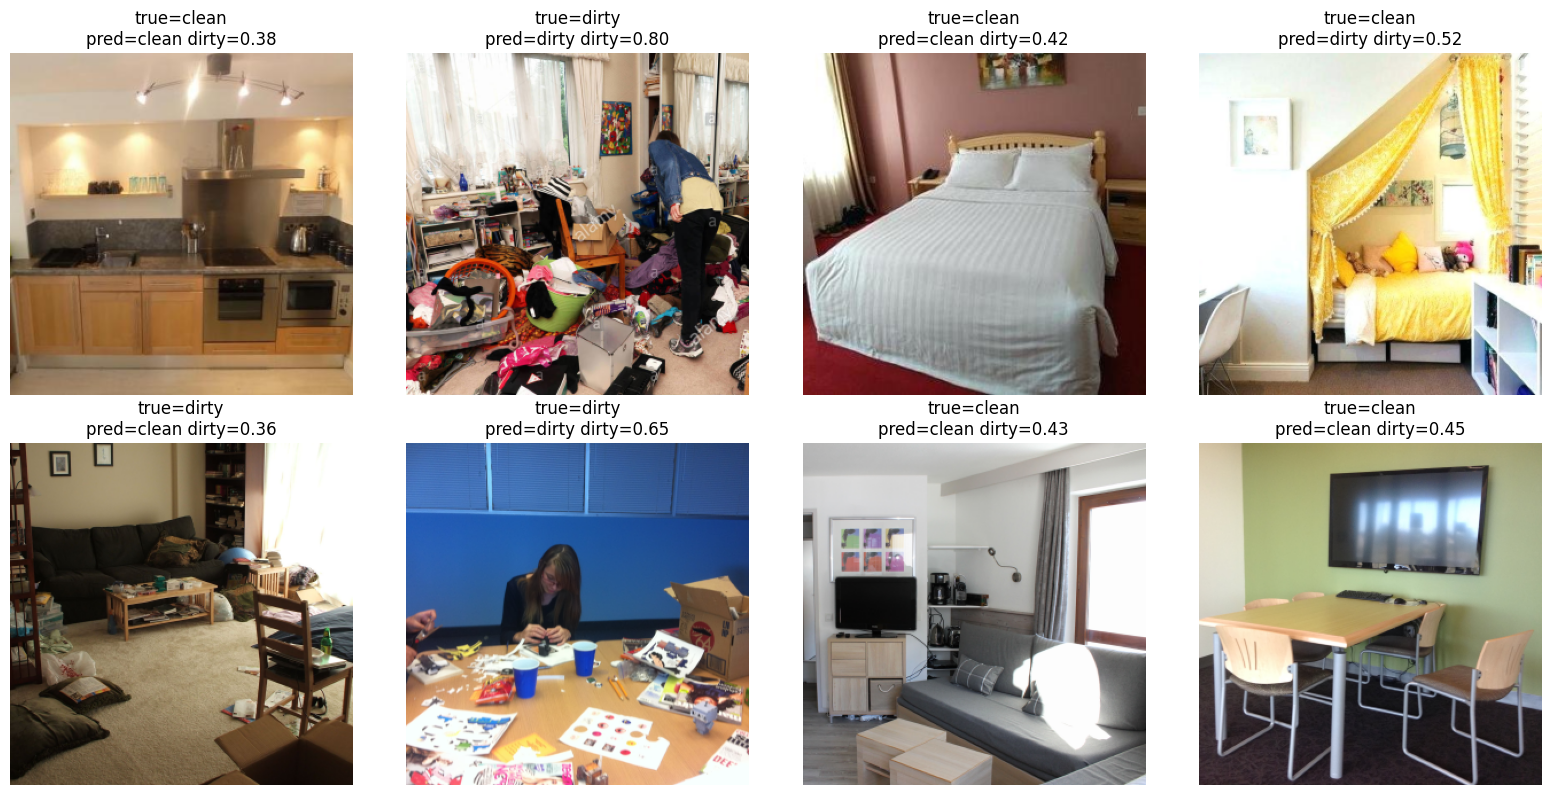

In [15]:
def show_test_predictions(count: int = 8) -> None:
    """Visual test cases with predicted labels and dirty probabilities."""
    model.eval()
    sample_indices = test_idx[:count]
    cols = min(count, 4)
    rows = math.ceil(count / cols)
    plt.figure(figsize=(4 * cols, 4 * rows))

    for plot_index, data_index in enumerate(sample_indices, start=1):
        image_bgr = images_bgr[data_index]
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        input_tensor = eval_transform(image_rgb).unsqueeze(0).to(DEVICE)

        with torch.inference_mode():
            probs = torch.softmax(model(input_tensor), dim=1)[0].cpu().numpy()

        pred_index = int(np.argmax(probs))
        true_index = int(labels[data_index])

        plt.subplot(rows, cols, plot_index)
        plt.imshow(image_rgb)
        plt.title(
            f"true={CLASS_NAMES[true_index]}\n"
            f"pred={CLASS_NAMES[pred_index]} dirty={probs[DIRTY_CLASS_INDEX]:.2f}"
        )
        plt.axis('off')

    plt.tight_layout()
    plt.show()


show_test_predictions(count=8)


## Save the Trained Model


In [16]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'class_names': CLASS_NAMES,
        'blur_threshold': BLUR_THRESHOLD,
        'min_brightness': MIN_BRIGHTNESS,
        'max_brightness': MAX_BRIGHTNESS,
        'fail_score_threshold': FAIL_SCORE_THRESHOLD,
    },
    MODEL_PATH,
)
print('Saved model to:', MODEL_PATH)


Saved model to: models/clean_dirty_efficientnet_b0.pt


## Final Controller: Quality Gate + EfficientNet Decision

This is the final pass/fail logic:

- If OpenCV quality check fails, return the OpenCV failure.
- If quality passes, run EfficientNet-B0.
- If dirty confidence is `>= FAIL_SCORE_THRESHOLD`, return `FAIL: Image classified as Dirty`.
- Otherwise return `PASS: Image is Clean`.


In [17]:
def predict_dirty_probability(image_bgr: np.ndarray, model: nn.Module) -> float:
    """Return the trained model's dirty probability for one OpenCV BGR image."""
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    input_tensor = eval_transform(image_rgb).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.inference_mode():
        logits = model(input_tensor)
        probabilities = torch.softmax(logits, dim=1)

    return float(probabilities[0, DIRTY_CLASS_INDEX].item())


def classify_image_array_with_pipeline(
    image_bgr: np.ndarray,
    model: nn.Module,
    fail_score_threshold: float = FAIL_SCORE_THRESHOLD,
) -> dict:
    """Run OpenCV quality gate and EfficientNet classification on an OpenCV image."""
    passed_quality, quality_message, quality_metrics = opencv_quality_gatekeeper(image_bgr)

    if not passed_quality:
        result = {
            'decision': quality_message,
            'dirty_probability': None,
            'quality_metrics': quality_metrics,
        }
        print(result['decision'])
        print(result['quality_metrics'])
        return result

    dirty_probability = predict_dirty_probability(image_bgr, model)
    decision = (
        'FAIL: Image classified as Dirty'
        if dirty_probability >= fail_score_threshold
        else 'PASS: Image is Clean'
    )

    result = {
        'decision': decision,
        'dirty_probability': dirty_probability,
        'quality_metrics': quality_metrics,
    }
    print(f"Quality gate: {quality_message}")
    print(f"Dirty probability: {dirty_probability:.4f}")
    print(decision)
    return result


def classify_image_url_with_pipeline(image_url: str, model: nn.Module) -> dict:
    """Download one image URL and run the complete pipeline."""
    image_bgr = download_image_from_url(image_url)
    return classify_image_array_with_pipeline(image_bgr, model)


## Test Case 1: Good Dataset Image


In [18]:
sample_index = test_idx[0]
sample_image = images_bgr[sample_index]
print('True label:', CLASS_NAMES[int(labels[sample_index])])
_ = classify_image_array_with_pipeline(sample_image, model)


True label: clean
Quality gate: PASS: Image quality is acceptable
Dirty probability: 0.3819
PASS: Image is Clean


## Test Case 2: Blurry Image Should Fail Quality Gate


In [19]:
blurry_image = cv2.GaussianBlur(sample_image, (41, 41), 0)
_ = classify_image_array_with_pipeline(blurry_image, model)


FAIL: Image too blurry
{'laplacian_variance': 1.7645998823597075, 'average_brightness': 133.5224214494245}


## Test Case 3: Dark Image Should Fail Quality Gate


In [20]:
dark_image = np.zeros_like(sample_image)
_ = classify_image_array_with_pipeline(dark_image, model)


FAIL: Image too blurry
{'laplacian_variance': 0.0, 'average_brightness': 0.0}


## Test Case 4: Classify Any Image URL

Replace `TEST_IMAGE_URL` with your own image URL. The notebook will download it, run the OpenCV checks, then classify it with the trained model.


In [21]:
TEST_IMAGE_URL = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg'

# Replace the URL above, then run this cell.
_ = classify_image_url_with_pipeline(TEST_IMAGE_URL, model)


Quality gate: PASS: Image quality is acceptable
Dirty probability: 0.5673
PASS: Image is Clean
